# Code Solver/Judge Difficulty Comparison

Load Code-domain K-factor item difficulty JSONs and keep each item's per-model scores. `code_solver` is LiveCodeBench solver-side; `code_judge` is CodeJudgeBench judge-side. CodeJudgeBench has multiple pairwise comparison rows per LiveCodeBench problem, so judge difficulty and judge scores are averaged to one row per `question_id` before joining to solver items.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 240)


## Choose K And Resolve Paths

In [2]:
MODEL_SELECTION_METRIC = "loss"  # lower held-out log loss is better



def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "K-Factor").exists() and (candidate / "benchmarks").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing K-Factor/ and benchmarks/")


REPO_ROOT = find_repo_root()
print(f"Repo root: {REPO_ROOT}")

solver_json_path = REPO_ROOT / "K-Factor" / "results" / "code_solver" / "code_solver_kfactor_item_difficulties_with_laplace_uncertainty.json"
judge_json_path = REPO_ROOT / "K-Factor" / "results" / "code_judge" / "code_judge_kfactor_item_difficulties_with_laplace_uncertainty.json"
solver_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "code_solver" / "code_solver_kfactor_fit_summary.csv"
judge_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "code_judge" / "code_judge_kfactor_fit_summary.csv"
solver_item_meta_path = REPO_ROOT / "benchmarks" / "code" / "response_matrices" / "livecodebench_item_metadata.csv"
judge_item_meta_path = REPO_ROOT / "benchmarks" / "code" / "response_matrices" / "codejudgebench_pairwise_item_metadata.csv"

out_dir = REPO_ROOT / "K-Factor" / "results" / "code_solver_judge_comparison"
out_dir.mkdir(parents=True, exist_ok=True)

for path in [solver_json_path, judge_json_path, solver_fit_summary_path, judge_fit_summary_path, solver_item_meta_path, judge_item_meta_path]:
    print(path.relative_to(REPO_ROOT), path.exists())


Repo root: /Users/dkoffical/Documents/GitHub/cs321m_project
K-Factor/results/code_solver/code_solver_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/code_judge/code_judge_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/code_solver/code_solver_kfactor_fit_summary.csv True
K-Factor/results/code_judge/code_judge_kfactor_fit_summary.csv True
benchmarks/code/response_matrices/livecodebench_item_metadata.csv True
benchmarks/code/response_matrices/codejudgebench_pairwise_item_metadata.csv True


## Fit Summaries

In [3]:
solver_fit_summary = pd.read_csv(solver_fit_summary_path)
judge_fit_summary = pd.read_csv(judge_fit_summary_path)


def choose_best_k(summary, metric="loss"):
    if metric == "loss":
        return summary.sort_values(["loss", "brier", "ece", "auc"], ascending=[True, True, True, False]).iloc[0]
    if metric == "auc":
        return summary.sort_values(["auc", "ece", "loss"], ascending=[False, True, True]).iloc[0]
    raise ValueError(f"Unknown model-selection metric: {metric}")

solver_best = choose_best_k(solver_fit_summary, MODEL_SELECTION_METRIC)
judge_best = choose_best_k(judge_fit_summary, MODEL_SELECTION_METRIC)

SOLVER_K = int(solver_best["k"])
JUDGE_K = int(judge_best["k"])
RUN_LABEL = f"solverk{SOLVER_K}_judgek{JUDGE_K}"

print(f"Model selection metric: held-out {MODEL_SELECTION_METRIC}")
print(f"Solver-side best k: k={SOLVER_K}")
print(f"Judge-side best k:  k={JUDGE_K}")
print(f"Loading {RUN_LABEL}")

print()
print("Solver fit summary")
display(solver_fit_summary.round(4))

print("Judge fit summary")
display(judge_fit_summary.round(4))

solver_fit_summary.to_csv(out_dir / "code_solver_kfactor_fit_summary.csv", index=False)
judge_fit_summary.to_csv(out_dir / "code_judge_kfactor_fit_summary.csv", index=False)


Model selection metric: held-out loss
Solver-side best k: k=1
Judge-side best k:  k=1
Loading solverk1_judgek1

Solver fit summary


,k,loss,loss_std,auc,auc_std,log_likelihood,log_likelihood_std,brier,brier_std,ece,ece_std,final_train_loss,final_train_auc,final_train_log_likelihood,final_train_brier,final_train_ece
0,1,0.4246,NaN,0.8528,NaN,-0.4246,NaN,0.0736,NaN,0.0498,NaN,0.1101,0.9985,-0.1101,0.0359,0.0187
1,2,1.0708,NaN,0.7131,NaN,-1.0708,NaN,0.1178,NaN,0.1073,NaN,0.0595,1.0000,-0.0595,0.0186,0.0130


Judge fit summary


,k,loss,loss_std,auc,auc_std,log_likelihood,log_likelihood_std,brier,brier_std,ece,ece_std,final_train_loss,final_train_auc,final_train_log_likelihood,final_train_brier,final_train_ece
0,1,1.0578,NaN,0.8069,NaN,-1.0578,NaN,0.1748,NaN,0.1302,NaN,0.1880,0.9349,-0.1880,0.0622,0.0252
1,2,1.4017,NaN,0.8137,NaN,-1.4017,NaN,0.1989,NaN,0.1742,NaN,0.1018,0.9757,-0.1018,0.0323,0.0159


## Load Item Difficulties And Scores

In [4]:
def load_kfactor_fit(json_path, k, score_col):
    with open(json_path) as f:
        payload = json.load(f)

    fit_key = f"k{k}"
    if fit_key not in payload["fits"]:
        raise KeyError(f"{json_path} does not contain {fit_key}; available={list(payload['fits'])}")

    df = pd.DataFrame(payload["fits"][fit_key])
    df["item_id"] = df["item_id"].astype(str)
    df = df.rename(columns={"scores": score_col})
    return df, payload


solver_items, solver_payload = load_kfactor_fit(solver_json_path, SOLVER_K, "solver_scores")
judge_pair_items, judge_payload = load_kfactor_fit(judge_json_path, JUDGE_K, "judge_pair_scores")

solver_items["question_id"] = solver_items["item_id"].astype(str)
judge_pair_items["question_id"] = judge_pair_items["question_id"].astype(str)

print(f"solver_items:     {solver_items.shape}")
print(f"judge_pair_items: {judge_pair_items.shape}")
print(f"solver unique question_id: {solver_items['question_id'].nunique()}")
print(f"judge unique question_id:  {judge_pair_items['question_id'].nunique()}")

solver_items.to_csv(out_dir / f"code_{RUN_LABEL}_solver_items.csv", index=False)
solver_items.to_json(out_dir / f"code_{RUN_LABEL}_solver_items.json", orient="records", indent=2, force_ascii=False)
judge_pair_items.to_csv(out_dir / f"code_{RUN_LABEL}_judge_pair_items.csv", index=False)
judge_pair_items.to_json(out_dir / f"code_{RUN_LABEL}_judge_pair_items.json", orient="records", indent=2, force_ascii=False)


solver_items:     (676, 19)
judge_pair_items: (2103, 19)
solver unique question_id: 676
judge unique question_id:  676


## Aggregate Judge Pairwise Items To Prompt Level

In [5]:
def mean_score_dict(dicts):
    models = sorted({model for scores in dicts if isinstance(scores, dict) for model in scores})
    averaged = {}
    for model in models:
        vals = []
        for scores in dicts:
            if isinstance(scores, dict):
                val = scores.get(model)
                if val is not None and not pd.isna(val):
                    vals.append(float(val))
        averaged[model] = float(np.mean(vals)) if vals else None
    return averaged


def combine_se_for_mean(values):
    vals = pd.Series(values).dropna().astype(float)
    if vals.empty:
        return np.nan
    return float(np.sqrt(np.square(vals).sum()) / len(vals))


def first_nonnull(series):
    nonnull = series.dropna()
    return nonnull.iloc[0] if len(nonnull) else None


judge_rows = []
for question_id, group in judge_pair_items.groupby("question_id", sort=False):
    judge_rows.append({
        "question_id": str(question_id),
        "judge_item_ids": list(group["item_id"].astype(str)),
        "judge_pair_ids": list(group["pair_id"].astype(str)) if "pair_id" in group else [],
        "judge_splits": sorted(group["split"].dropna().astype(str).unique().tolist()) if "split" in group else [],
        "judge_orderings": sorted(group["ordering"].dropna().astype(str).unique().tolist()) if "ordering" in group else [],
        "judge_gold_labels": dict(zip(group["item_id"].astype(str), group["gold"].astype(str))) if "gold" in group else {},
        "judge_n_pair_items": int(len(group)),
        "judge_difficulty_meta": first_nonnull(group["difficulty_meta"]) if "difficulty_meta" in group else first_nonnull(group.get("difficulty", pd.Series(dtype=object))),
        "judge_difficulty": float(group["difficulty"].mean()),
        "judge_difficulty_centered": float(group["difficulty_centered"].mean()),
        "judge_difficulty_pair_sd": float(group["difficulty_centered"].std(ddof=1)) if len(group) > 1 else 0.0,
        "judge_difficulty_laplace_se": combine_se_for_mean(group["difficulty_laplace_se"]),
        "judge_difficulty_centered_laplace_se": combine_se_for_mean(group["difficulty_centered_laplace_se"]),
        "judge_dominant_factors": dict(zip(group["item_id"].astype(str), group["dominant_factor"].astype(str))) if "dominant_factor" in group else {},
        "judge_scores": mean_score_dict(group["judge_pair_scores"]),
    })

judge_items = pd.DataFrame(judge_rows)
print(f"judge_items aggregated: {judge_items.shape}")
print("judge pair items per question_id")
display(judge_items["judge_n_pair_items"].describe().to_frame().T)
display(judge_items.head())

judge_items.to_csv(out_dir / f"code_{RUN_LABEL}_judge_items_aggregated.csv", index=False)
judge_items.to_json(out_dir / f"code_{RUN_LABEL}_judge_items_aggregated.json", orient="records", indent=2, force_ascii=False)


judge_items aggregated: (676, 15)
judge pair items per question_id


,count,mean,std,min,25%,50%,75%,max
judge_n_pair_items,676.0,3.110947,1.753168,1.0,2.0,3.0,4.0,7.0


,question_id,judge_item_ids,judge_pair_ids,judge_splits,judge_orderings,judge_gold_labels,judge_n_pair_items,judge_difficulty_meta,judge_difficulty,judge_difficulty_centered,judge_difficulty_pair_sd,judge_difficulty_laplace_se,judge_difficulty_centered_laplace_se,judge_dominant_factors,judge_scores
0,abc338_c,[gemini_2.5_flash_lite:abc338_c:237:bwd],[gemini_2.5_flash_lite:abc338_c:237],[gemini_2.5_flash_lite],[bwd],{'gemini_2.5_flash_lite:abc338_c:237:bwd': 'B'},1,hard,18.850096,20.485847,0.000000,3.156946,3.156541,{'gemini_2.5_flash_lite:abc338_c:237:bwd': 'factor_1'},"{'claude_haiku_4_5': 0.0, 'mistral_14b': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_27b': 0.0, 'qwen3_5_2b': 1.0, 'qwen3_5_4b': 1.0, 'qwen3_5_9b': 0.0}"
1,3558,"[claude_3.7_sonnet:3558:236:bwd, gemini_2.5_flash_lite:3558:104:bwd, gemini_2.5_flash:3558:349:fwd, qwen3_235b:3558:53:fwd]","[claude_3.7_sonnet:3558:236, gemini_2.5_flash_lite:3558:104, gemini_2.5_flash:3558:349, qwen3_235b:3558:53]","[claude_3.7_sonnet, gemini_2.5_flash, gemini_2.5_flash_lite, qwen3_235b]","[bwd, fwd]","{'claude_3.7_sonnet:3558:236:bwd': 'B', 'gemini_2.5_flash_lite:3558:104:bwd': 'B', 'gemini_2.5_flash:3558:349:fwd': 'A', 'qwen3_235b:3558:53:fwd': 'A'}",4,medium,3.264904,4.900656,7.404716,2.126866,2.126261,"{'claude_3.7_sonnet:3558:236:bwd': 'factor_1', 'gemini_2.5_flash_lite:3558:104:bwd': 'factor_1', 'gemini_2.5_flash:3558:349:fwd': 'factor_1', 'qwen3_235b:3558:53:fwd': 'factor_1'}","{'claude_haiku_4_5': 0.25, 'mistral_14b': 0.5, 'mistral_3b': 0.5, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 0.5, 'qwen3_5_27b': 0.75, 'qwen3_5_2b': 0.25, 'qwen3_5_4b': 0.5, 'qwen3_5_9b': 0.25}"
2,3453,"[claude_3.7_sonnet:3453:48:bwd, gemini_2.5_flash:3453:52:bwd, claude_4_opus:3453:39:bwd, claude_4_sonnet:3453:61:bwd, gemini_2.5_flash_lite:3453:81:fwd, gemini_2.5_pro:3453:19:fwd]","[claude_3.7_sonnet:3453:48, gemini_2.5_flash:3453:52, claude_4_opus:3453:39, claude_4_sonnet:3453:61, gemini_2.5_flash_lite:3453:81, gemini_2.5_pro:3453:19]","[claude_3.7_sonnet, claude_4_opus, claude_4_sonnet, gemini_2.5_flash, gemini_2.5_flash_lite, gemini_2.5_pro]","[bwd, fwd]","{'claude_3.7_sonnet:3453:48:bwd': 'B', 'gemini_2.5_flash:3453:52:bwd': 'B', 'claude_4_opus:3453:39:bwd': 'B', 'claude_4_sonnet:3453:61:bwd': 'B', 'gemini_2.5_flash_lite:3453:81:fwd': 'A', 'gemini_2.5_pro:3453:19:fwd': 'A'}",6,hard,4.413649,6.049401,6.246708,2.111251,2.110521,"{'claude_3.7_sonnet:3453:48:bwd': 'factor_1', 'gemini_2.5_flash:3453:52:bwd': 'factor_1', 'claude_4_opus:3453:39:bwd': 'factor_1', 'claude_4_sonnet:3453:61:bwd': 'factor_1', 'gemini_2.5_flash_lite:3453:81:fwd': 'factor_1', 'gemini_2.5_p...","{'claude_haiku_4_5': 0.3333333333333333, 'mistral_14b': 0.3333333333333333, 'mistral_3b': 0.3333333333333333, 'mistral_8b': 0.3333333333333333, 'qwen3_5_0_8b': 0.3333333333333333, 'qwen3_5_27b': 0.3333333333333333, 'qwen3_5_2b': 0.66666..."
3,3535,"[gemini_2.5_flash_lite:3535:100:bwd, claude_3.7_sonnet:3535:235:bwd]","[gemini_2.5_flash_lite:3535:100, claude_3.7_sonnet:3535:235]","[claude_3.7_sonnet, gemini_2.5_flash_lite]",[bwd],"{'gemini_2.5_flash_lite:3535:100:bwd': 'B', 'claude_3.7_sonnet:3535:235:bwd': 'B'}",2,medium,6.389013,8.024765,10.319204,1.163749,1.164683,"{'gemini_2.5_flash_lite:3535:100:bwd': 'factor_1', 'claude_3.7_sonnet:3535:235:bwd': 'factor_1'}","{'claude_haiku_4_5': 0.0, 'mistral_14b': 0.5, 'mistral_3b': 0.5, 'mistral_8b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_27b': 0.5, 'qwen3_5_2b': 1.0, 'qwen3_5_4b': 1.0, 'qwen3_5_9b': 0.5}"
4,3406,"[qwen3_235b:3406:33:bwd, gemini_2.5_pro:3406:15:bwd, claude_4_sonnet:3406:55:fwd, gemini_2.5_flash_lite:3406:73:bwd, claude_4_opus:3406:32:bwd, gemini_2.5_flash:3406:46:fwd, claude_3.7_sonnet:3406:43:bwd]","[qwen3_235b:3406:33, gemini_2.5_pro:3406:15, claude_4_sonnet:3406:55, gemini_2.5_flash_lite:3406:73, claude_4_opus:3406:32, gemini_2.5_flash:3406:46, claude_3.7_sonnet:3406:43]","[claude_3.7_sonnet, claude_4_opus, claude_4_sonnet, gemini_2.5_flash, gemini_2.5_flash_l

## Join Solver And Judge Items

In [6]:
def prefix_solver_cols(df):
    keep = {"question_id", "solver_scores"}
    return df.rename(columns={col: f"solver_{col}" for col in df.columns if col not in keep})


def prefix_judge_cols(df):
    keep = {"question_id", "judge_scores"}
    return df.rename(columns={col: f"judge_{col}" for col in df.columns if col not in keep and not col.startswith("judge_")})


solver_for_join = solver_items.rename(columns={"scores": "solver_scores"}) if "scores" in solver_items.columns else solver_items.copy()
solver_for_join = prefix_solver_cols(solver_for_join)
judge_for_join = prefix_judge_cols(judge_items)

paired_items = solver_for_join.merge(judge_for_join, on="question_id", how="inner")

print(f"paired_items: {paired_items.shape}")
print(f"solver-only question_id: {solver_items['question_id'].nunique() - paired_items['question_id'].nunique()}")
print(f"judge-only question_id:  {judge_items['question_id'].nunique() - paired_items['question_id'].nunique()}")
display(paired_items.head())

paired_items.to_csv(out_dir / f"code_{RUN_LABEL}_paired_items.csv", index=False)
paired_items.to_json(out_dir / f"code_{RUN_LABEL}_paired_items.json", orient="records", indent=2, force_ascii=False)


paired_items: (676, 33)
solver-only question_id: 0
judge-only question_id:  0


,solver_item_id,solver_difficulty,solver_difficulty_centered,solver_easiness_z,solver_loading_factor_1,solver_dominant_factor,solver_item_id_meta,solver_selected_order,solver_difficulty_meta,solver_platform,solver_question_content,solver_starter_code,solver_prompt,solver_difficulty_laplace_se,solver_difficulty_centered_laplace_se,solver_difficulty_centered_laplace_lo,solver_difficulty_centered_laplace_hi,solver_scores,question_id,judge_item_ids,judge_pair_ids,judge_splits,judge_orderings,judge_gold_labels,judge_n_pair_items,judge_difficulty_meta,judge_difficulty,judge_difficulty_centered,judge_difficulty_pair_sd,judge_difficulty_laplace_se,judge_difficulty_centered_laplace_se,judge_dominant_factors,judge_scores
0,3558,6.645246,6.556765,-6.645246,-3.604957,factor_1,3558,195,medium,leetcode,None,None,None,27.586109,27.546213,-47.433811,60.547344,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",3558,"[claude_3.7_sonnet:3558:236:bwd, gemini_2.5_flash_lite:3558:104:bwd, gemini_2.5_flash:3558:349:fwd, qwen3_235b:3558:53:fwd]","[claude_3.7_sonnet:3558:236, gemini_2.5_flash_lite:3558:104, gemini_2.5_flash:3558:349, qwen3_235b:3558:53]","[claude_3.7_sonnet, gemini_2.5_flash, gemini_2.5_flash_lite, qwen3_235b]","[bwd, fwd]","{'claude_3.7_sonnet:3558:236:bwd': 'B', 'gemini_2.5_flash_lite:3558:104:bwd': 'B', 'gemini_2.5_flash:3558:349:fwd': 'A', 'qwen3_235b:3558:53:fwd': 'A'}",4,medium,3.264904,4.900656,7.404716,2.126866,2.126261,"{'claude_3.7_sonnet:3558:236:bwd': 'factor_1', 'gemini_2.5_flash_lite:3558:104:bwd': 'factor_1', 'gemini_2.5_flash:3558:349:fwd': 'factor_1', 'qwen3_235b:3558:53:fwd': 'factor_1'}","{'claude_haiku_4_5': 0.25, 'mistral_14b': 0.5, 'mistral_3b': 0.5, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 0.5, 'qwen3_5_27b': 0.75, 'qwen3_5_2b': 0.25, 'qwen3_5_4b': 0.5, 'qwen3_5_9b': 0.25}"
1,2730,6.324811,6.236330,-6.324811,-1.706195,factor_1,2730,7,medium,leetcode,None,None,None,19.197617,19.170551,-31.337950,43.810608,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",2730,[gemini_2.5_flash:2730:303:bwd],[gemini_2.5_flash:2730:303],[gemini_2.5_flash],[bwd],{'gemini_2.5_flash:2730:303:bwd': 'B'},1,easy,-7.563495,-5.927743,0.000000,5.300238,5.298371,{'gemini_2.5_flash:2730:303:bwd': 'factor_1'},"{'claude_haiku_4_5': 1.0, 'mistral_14b': 1.0, 'mistral_3b': 0.0, 'mistral_8b': 1.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_27b': 1.0, 'qwen3_5_2b': 1.0, 'qwen3_5_4b': 1.0, 'qwen3_5_9b': 1.0}"
2,3777,5.957350,5.868869,-5.957350,-3.410881,factor_1,3777,278,hard,leetcode,None,None,None,19.386602,19.359243,-32.075249,43.812988,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",3777,"[claude_3.7_sonnet:3777:88:fwd, claude_4_sonnet:3777:119:fwd, gemini_2.5_flash_lite:3777:164:fwd]","[claude_3.7_sonnet:3777:88, claude_4_sonnet:3777:119, gemini_2.5_flash_lite:3777:164]","[claude_3.7_sonnet, claude_4_sonnet, gemini_2.5_flash_lite]",[fwd],"{'claude_3.7_sonnet:3777:88:fwd': 'A', 'claude_4_sonnet:3777:119:fwd': 'A', 'gemini_2.5_flash_lite:3777:164:fwd': 'A'}",3,hard,-1.304495,0.331257,4.629187,1.065639,1.066215,"{'claude_3.7_sonnet:3777:88:fwd': 'factor_1', 'claude_4_sonnet:3777:119:fwd': 'factor_1', 'gemini_2.5_flash_lite:3777:164:fwd': 'factor_1'}","{'claude_haiku_4_5': 0.3333333333333333, 'mistral_14b': 0.6666666666666666, 'mistral_3b': 0.6666666666666666, 'mistral_8b': 1.0, 'qwen3_5_0_8b': 0.6666666666666666, 'qwen3_5_27b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b':..."
3,2854,5.895410,5.806929,-5.895410,-4.195698,factor_1,2854,30,medium,leetcode,None,None,None,19.433870,19.406439,-32.229691,43.843552,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistra

## Analysis 1: Judge Scores By Solver Difficulty Bin

In [7]:
def score_mean(scores):
    if not isinstance(scores, dict):
        return np.nan
    vals = [float(v) for v in scores.values() if v is not None and not pd.isna(v)]
    return float(np.mean(vals)) if vals else np.nan


partone_table = paired_items[[
    "question_id",
    "solver_item_id",
    "solver_difficulty_meta",
    "solver_platform",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "solver_scores",
    "judge_scores",
    "judge_n_pair_items",
]].copy()

partone_table["judge_score_mean"] = partone_table["judge_scores"].apply(score_mean)
partone_table_sorted = partone_table.sort_values("solver_difficulty_centered", ascending=False)

display(partone_table_sorted.head())

partone_table.to_csv(out_dir / f"code_{RUN_LABEL}_partone_table_with_judge_score_mean.csv", index=False)
partone_table.to_json(out_dir / f"code_{RUN_LABEL}_partone_table_with_judge_score_mean.json", orient="records", indent=2, force_ascii=False)
partone_table_sorted.to_csv(out_dir / f"code_{RUN_LABEL}_partone_table_sorted.csv", index=False)
partone_table_sorted.to_json(out_dir / f"code_{RUN_LABEL}_partone_table_sorted.json", orient="records", indent=2, force_ascii=False)


,question_id,solver_item_id,solver_difficulty_meta,solver_platform,solver_difficulty_centered,solver_difficulty_centered_laplace_se,solver_scores,judge_scores,judge_n_pair_items,judge_score_mean
0,3558,3558,medium,leetcode,6.556765,27.546213,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}","{'claude_haiku_4_5': 0.25, 'mistral_14b': 0.5, 'mistral_3b': 0.5, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 0.5, 'qwen3_5_27b': 0.75, 'qwen3_5_2b': 0.25, 'qwen3_5_4b': 0.5, 'qwen3_5_9b': 0.25}",4,0.444444
1,2730,2730,medium,leetcode,6.236330,19.170551,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}","{'claude_haiku_4_5': 1.0, 'mistral_14b': 1.0, 'mistral_3b': 0.0, 'mistral_8b': 1.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_27b': 1.0, 'qwen3_5_2b': 1.0, 'qwen3_5_4b': 1.0, 'qwen3_5_9b': 1.0}",1,0.777778
2,3777,3777,hard,leetcode,5.868869,19.359243,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}","{'claude_haiku_4_5': 0.3333333333333333, 'mistral_14b': 0.6666666666666666, 'mistral_3b': 0.6666666666666666, 'mistral_8b': 1.0, 'qwen3_5_0_8b': 0.6666666666666666, 'qwen3_5_27b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b':...",3,0.370370
3,2854,2854,medium,leetcode,5.806929,19.406439,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}","{'claude_haiku_4_5': 0.5, 'mistral_14b': 0.5, 'mistral_3b': 1.0, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 1.0, 'qwen3_5_27b': 0.5, 'qwen3_5_2b': 0.5, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.5}",2,0.555556
4,3771,3771,medium,leetcode,5.733614,18.431330,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}","{'claude_haiku_4_5': 0.3333333333333333, 'mistral_14b': 0.3333333333333333, 'mistral_3b': 0.6666666666666666, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 0.6666666666666666, 'qwen3_5_27b': 0.16666666666666666, 'qwen3_5_2b': 0.5, 'qwen3_5_4b': 0....",6,0.407407


## Plot: Mean Judge Score Across Solver Difficulty Deciles

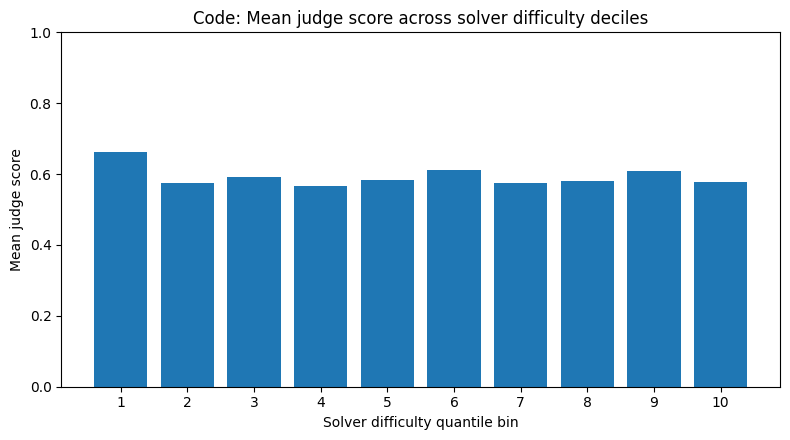

,difficulty_bin,solver_difficulty_mean,judge_score_mean,judge_score_sd,n_items,n_judge_pair_items
0,1,-10.289907,0.663276,0.149042,68,170
1,2,-5.262677,0.574296,0.151156,68,208
2,3,-2.790112,0.592762,0.169535,67,184
3,4,-1.789794,0.565706,0.120820,68,215
4,5,0.767426,0.582605,0.182046,67,204
5,6,3.092781,0.611864,0.150631,68,214
6,7,3.418520,0.575663,0.147117,67,221
7,8,3.746744,0.581577,0.157415,68,230
8,9,4.210755,0.608993,0.156365,67,220
9,10,4.978715,0.577190,0.159667,68,237


In [8]:
plot_df = partone_table.copy()
plot_df["difficulty_bin"] = pd.qcut(
    plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
) + 1

bin_summary = (
    plot_df
    .groupby("difficulty_bin", observed=True)
    .agg(
        solver_difficulty_mean=("solver_difficulty_centered", "mean"),
        judge_score_mean=("judge_score_mean", "mean"),
        judge_score_sd=("judge_score_mean", "std"),
        n_items=("solver_item_id", "count"),
        n_judge_pair_items=("judge_n_pair_items", "sum"),
    )
    .reset_index()
)

plt.figure(figsize=(8, 4.5))
plt.bar(bin_summary["difficulty_bin"], bin_summary["judge_score_mean"])
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Code: Mean judge score across solver difficulty deciles")
plt.xticks(bin_summary["difficulty_bin"])
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(out_dir / f"code_{RUN_LABEL}_difficulty_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"code_{RUN_LABEL}_difficulty_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(bin_summary)

bin_summary.to_csv(out_dir / f"code_{RUN_LABEL}_difficulty_bin_summary.csv", index=False)
bin_summary.to_json(out_dir / f"code_{RUN_LABEL}_difficulty_bin_summary.json", orient="records", indent=2, force_ascii=False)


## Plot: Distribution Across Judge Models Within Each Solver Difficulty Bin

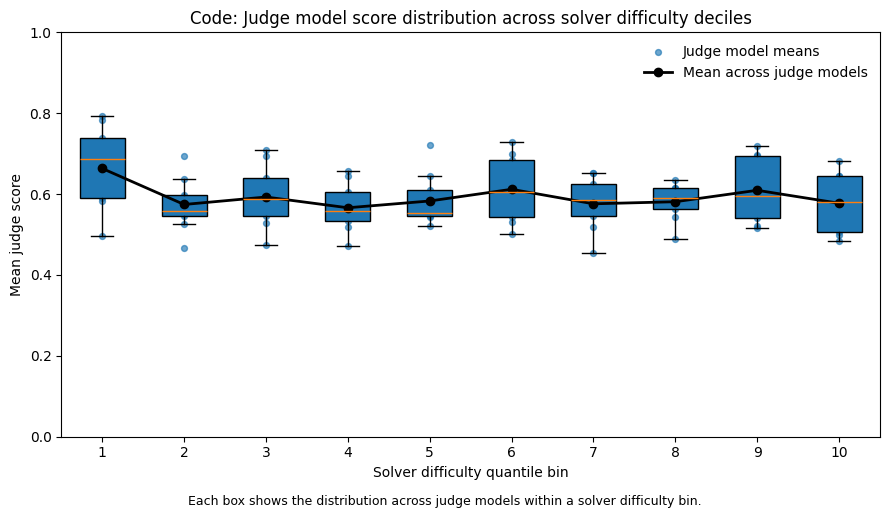

,difficulty_bin,judge_model,judge_score_mean,n_items
0,1,claude_haiku_4_5,0.739216,68
1,1,mistral_14b,0.687313,67
2,1,mistral_3b,0.607843,68
3,1,mistral_8b,0.687255,68
4,1,qwen3_5_0_8b,0.497549,68
...,...,...,...,...
85,10,qwen3_5_0_8b,0.482948,68
86,10,qwen3_5_27b,0.681618,68
87,10,qwen3_5_2b,0.507248,68
88,10,qwen3_5_4b,0.498704,68


,difficulty_bin,judge_score_mean,judge_score_sd,n_judge_models
0,1,0.663378,0.100548,9
1,2,0.574296,0.066209,9
2,3,0.592762,0.077726,9
3,4,0.566179,0.059904,9
4,5,0.582961,0.064065,9
5,6,0.611830,0.080465,9
6,7,0.575961,0.064792,9
7,8,0.581110,0.044262,9
8,9,0.609383,0.078356,9
9,10,0.577348,0.073405,9


In [9]:
model_plot_df = partone_table.copy()
model_plot_df["difficulty_bin"] = pd.qcut(
    model_plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
) + 1

judge_model_rows = []
for _, row in model_plot_df.iterrows():
    scores = row["judge_scores"]
    if not isinstance(scores, dict):
        continue
    for judge_model, score in scores.items():
        if score is None or pd.isna(score):
            continue
        judge_model_rows.append({
            "difficulty_bin": int(row["difficulty_bin"]),
            "question_id": row["question_id"],
            "judge_model": judge_model,
            "judge_score": float(score),
        })

judge_model_scores = pd.DataFrame(judge_model_rows)
judge_model_bin_summary = (
    judge_model_scores
    .groupby(["difficulty_bin", "judge_model"], observed=True)
    .agg(
        judge_score_mean=("judge_score", "mean"),
        n_items=("question_id", "count"),
    )
    .reset_index()
)

judge_model_bin_mean = (
    judge_model_bin_summary
    .groupby("difficulty_bin", observed=True)
    .agg(
        judge_score_mean=("judge_score_mean", "mean"),
        judge_score_sd=("judge_score_mean", "std"),
        n_judge_models=("judge_model", "count"),
    )
    .reset_index()
)

bins = sorted(judge_model_bin_summary["difficulty_bin"].unique())
box_data = [
    judge_model_bin_summary.loc[judge_model_bin_summary["difficulty_bin"] == bin_id, "judge_score_mean"].to_numpy()
    for bin_id in bins
]

plt.figure(figsize=(9, 5))
plt.boxplot(box_data, positions=bins, widths=0.55, patch_artist=True, showfliers=False)
plt.scatter(
    judge_model_bin_summary["difficulty_bin"],
    judge_model_bin_summary["judge_score_mean"],
    s=18,
    alpha=0.65,
    color="tab:blue",
    label="Judge model means",
)
plt.plot(
    judge_model_bin_mean["difficulty_bin"],
    judge_model_bin_mean["judge_score_mean"],
    color="black",
    marker="o",
    linewidth=2,
    label="Mean across judge models",
)
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Code: Judge model score distribution across solver difficulty deciles")
plt.xticks(bins)
plt.ylim(0, 1)
plt.legend(frameon=False)
plt.figtext(
    0.5,
    -0.02,
    "Each box shows the distribution across judge models within a solver difficulty bin.",
    ha="center",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(out_dir / f"code_{RUN_LABEL}_judge_model_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"code_{RUN_LABEL}_judge_model_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(judge_model_bin_summary)
display(judge_model_bin_mean)

judge_model_bin_summary.to_csv(out_dir / f"code_{RUN_LABEL}_judge_model_bin_summary.csv", index=False)
judge_model_bin_summary.to_json(out_dir / f"code_{RUN_LABEL}_judge_model_bin_summary.json", orient="records", indent=2, force_ascii=False)
judge_model_bin_mean.to_csv(out_dir / f"code_{RUN_LABEL}_judge_model_bin_summary_mean.csv", index=False)
judge_model_bin_mean.to_json(out_dir / f"code_{RUN_LABEL}_judge_model_bin_summary_mean.json", orient="records", indent=2, force_ascii=False)


## Analysis 2: Solver Difficulty Vs Aggregated Judge Difficulty

In [10]:
parttwo_table = paired_items[[
    "question_id",
    "solver_item_id",
    "solver_difficulty_meta",
    "solver_platform",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "solver_scores",
    "judge_difficulty_centered",
    "judge_difficulty_centered_laplace_se",
    "judge_difficulty_pair_sd",
    "judge_n_pair_items",
    "judge_scores",
]].copy()

parttwo_table_sorted = parttwo_table.sort_values("solver_difficulty_centered", ascending=False)

display(parttwo_table_sorted.head())

parttwo_table.to_csv(out_dir / f"code_{RUN_LABEL}_parttwo_table_raw.csv", index=False)
parttwo_table.to_json(out_dir / f"code_{RUN_LABEL}_parttwo_table_raw.json", orient="records", indent=2, force_ascii=False)
parttwo_table_sorted.to_csv(out_dir / f"code_{RUN_LABEL}_parttwo_table_sorted.csv", index=False)
parttwo_table_sorted.to_json(out_dir / f"code_{RUN_LABEL}_parttwo_table_sorted.json", orient="records", indent=2, force_ascii=False)


,question_id,solver_item_id,solver_difficulty_meta,solver_platform,solver_difficulty_centered,solver_difficulty_centered_laplace_se,solver_scores,judge_difficulty_centered,judge_difficulty_centered_laplace_se,judge_difficulty_pair_sd,judge_n_pair_items,judge_scores
0,3558,3558,medium,leetcode,6.556765,27.546213,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",4.900656,2.126261,7.404716,4,"{'claude_haiku_4_5': 0.25, 'mistral_14b': 0.5, 'mistral_3b': 0.5, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 0.5, 'qwen3_5_27b': 0.75, 'qwen3_5_2b': 0.25, 'qwen3_5_4b': 0.5, 'qwen3_5_9b': 0.25}"
1,2730,2730,medium,leetcode,6.236330,19.170551,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",-5.927743,5.298371,0.000000,1,"{'claude_haiku_4_5': 1.0, 'mistral_14b': 1.0, 'mistral_3b': 0.0, 'mistral_8b': 1.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_27b': 1.0, 'qwen3_5_2b': 1.0, 'qwen3_5_4b': 1.0, 'qwen3_5_9b': 1.0}"
2,3777,3777,hard,leetcode,5.868869,19.359243,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",0.331257,1.066215,4.629187,3,"{'claude_haiku_4_5': 0.3333333333333333, 'mistral_14b': 0.6666666666666666, 'mistral_3b': 0.6666666666666666, 'mistral_8b': 1.0, 'qwen3_5_0_8b': 0.6666666666666666, 'qwen3_5_27b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b':..."
3,2854,2854,medium,leetcode,5.806929,19.406439,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",1.613278,3.835731,11.689973,2,"{'claude_haiku_4_5': 0.5, 'mistral_14b': 0.5, 'mistral_3b': 1.0, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 1.0, 'qwen3_5_27b': 0.5, 'qwen3_5_2b': 0.5, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.5}"
4,3771,3771,medium,leetcode,5.733614,18.431330,"{'claude_haiku_4_5': 0.0, 'mistral_3b': 0.0, 'mistral_8b': 0.0, 'mistral_14b': 0.0, 'qwen3_5_0_8b': 0.0, 'qwen3_5_2b': 0.0, 'qwen3_5_4b': 0.0, 'qwen3_5_9b': 0.0, 'qwen3_5_27b': 0.0}",3.658842,1.656314,6.836657,6,"{'claude_haiku_4_5': 0.3333333333333333, 'mistral_14b': 0.3333333333333333, 'mistral_3b': 0.6666666666666666, 'mistral_8b': 0.5, 'qwen3_5_0_8b': 0.6666666666666666, 'qwen3_5_27b': 0.16666666666666666, 'qwen3_5_2b': 0.5, 'qwen3_5_4b': 0...."


## Plot: Solver Difficulty Vs Aggregated Judge Difficulty

Spearman rho = 0.0297, p = 0.4411, n = 676


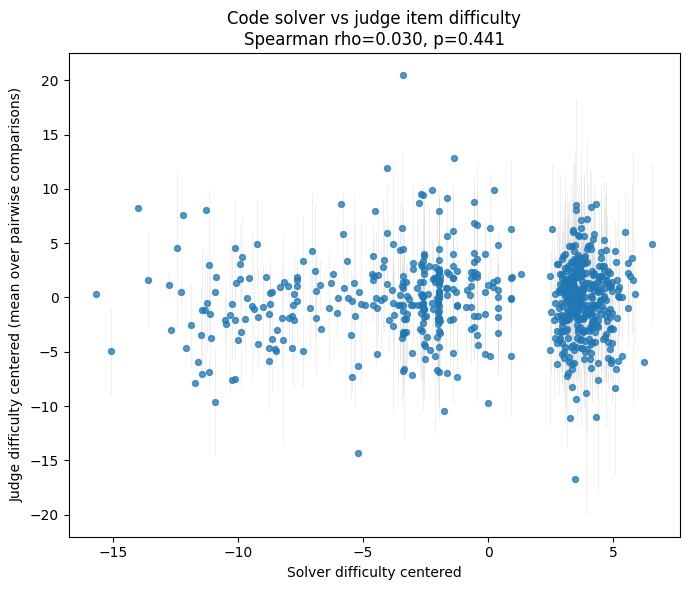

,question_id,solver_item_id,solver_difficulty_meta,solver_platform,solver_difficulty_centered,solver_difficulty_centered_laplace_se,judge_difficulty_centered,judge_difficulty_centered_laplace_se,judge_difficulty_pair_sd,judge_n_pair_items
0,3558,3558,medium,leetcode,6.556765,27.546213,4.900656,2.126261,7.404716,4
1,2730,2730,medium,leetcode,6.236330,19.170551,-5.927743,5.298371,0.000000,1
2,3777,3777,hard,leetcode,5.868869,19.359243,0.331257,1.066215,4.629187,3
3,2854,2854,medium,leetcode,5.806929,19.406439,1.613278,3.835731,11.689973,2
4,3771,3771,medium,leetcode,5.733614,18.431330,3.658842,1.656314,6.836657,6


In [11]:
parttwo_difficulty_df = parttwo_table[[
    "question_id",
    "solver_item_id",
    "solver_difficulty_meta",
    "solver_platform",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "judge_difficulty_centered",
    "judge_difficulty_centered_laplace_se",
    "judge_difficulty_pair_sd",
    "judge_n_pair_items",
]].copy()

rho, p_value = spearmanr(
    parttwo_difficulty_df["solver_difficulty_centered"],
    parttwo_difficulty_df["judge_difficulty_centered"],
    nan_policy="omit",
)
print(f"Spearman rho = {rho:.4f}, p = {p_value:.4g}, n = {len(parttwo_difficulty_df)}")

plt.figure(figsize=(7, 6))
# Error bars show variation across pairwise CodeJudgeBench judgments for the same prompt.
# Prompts with one pairwise judgment have zero within-prompt SD.
plt.errorbar(
    parttwo_difficulty_df["solver_difficulty_centered"],
    parttwo_difficulty_df["judge_difficulty_centered"],
    yerr=parttwo_difficulty_df["judge_difficulty_pair_sd"].fillna(0),
    fmt="none",
    ecolor="lightgray",
    elinewidth=0.7,
    alpha=0.35,
    zorder=1,
)
plt.scatter(
    parttwo_difficulty_df["solver_difficulty_centered"],
    parttwo_difficulty_df["judge_difficulty_centered"],
    s=18,
    alpha=0.75,
    zorder=2,
)
plt.xlabel("Solver difficulty centered")
plt.ylabel("Judge difficulty centered (mean over pairwise comparisons)")
plt.title(f"Code solver vs judge item difficulty\nSpearman rho={rho:.3f}, p={p_value:.3g}")
plt.tight_layout()
plt.savefig(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_scatter.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_scatter.pdf", bbox_inches="tight")
plt.show()

display(parttwo_difficulty_df.head())

parttwo_difficulty_df.to_csv(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_scatter.csv", index=False)
parttwo_difficulty_df.to_json(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_scatter.json", orient="records", indent=2, force_ascii=False)


## Plot: Solver Difficulty Percentile Vs Judge Difficulty Percentile

Percentile Spearman rho = 0.0297, p = 0.4411, n = 676


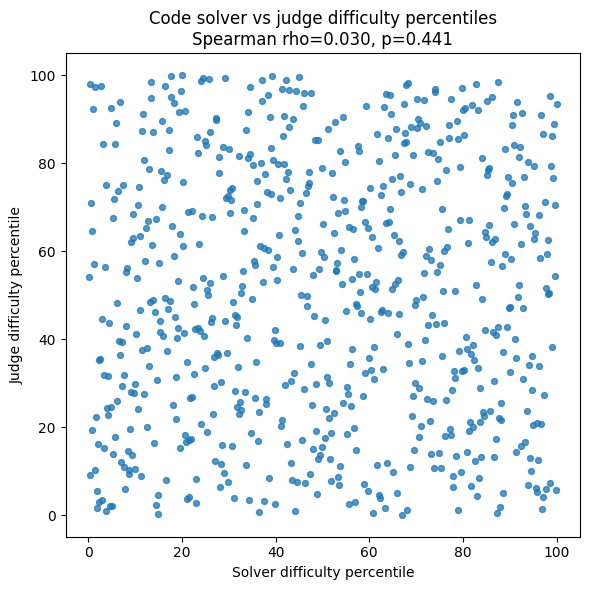

,question_id,solver_item_id,solver_difficulty_meta,solver_platform,solver_difficulty_centered,solver_difficulty_centered_laplace_se,judge_difficulty_centered,judge_difficulty_centered_laplace_se,judge_difficulty_pair_sd,judge_n_pair_items,solver_difficulty_percentile,judge_difficulty_percentile
0,3558,3558,medium,leetcode,6.556765,27.546213,4.900656,2.126261,7.404716,4,100.000000,93.491124
1,2730,2730,medium,leetcode,6.236330,19.170551,-5.927743,5.298371,0.000000,1,99.852071,5.769231
2,3777,3777,hard,leetcode,5.868869,19.359243,0.331257,1.066215,4.629187,3,99.704142,54.437870
3,2854,2854,medium,leetcode,5.806929,19.406439,1.613278,3.835731,11.689973,2,99.556213,70.562130
4,3771,3771,medium,leetcode,5.733614,18.431330,3.658842,1.656314,6.836657,6,99.408284,88.905325


In [12]:
percentile_df = parttwo_difficulty_df.copy()
percentile_df["solver_difficulty_percentile"] = percentile_df["solver_difficulty_centered"].rank(pct=True) * 100
percentile_df["judge_difficulty_percentile"] = percentile_df["judge_difficulty_centered"].rank(pct=True) * 100

rho_pct, p_pct = spearmanr(
    percentile_df["solver_difficulty_percentile"],
    percentile_df["judge_difficulty_percentile"],
    nan_policy="omit",
)
print(f"Percentile Spearman rho = {rho_pct:.4f}, p = {p_pct:.4g}, n = {len(percentile_df)}")

plt.figure(figsize=(6, 6))
plt.scatter(
    percentile_df["solver_difficulty_percentile"],
    percentile_df["judge_difficulty_percentile"],
    s=18,
    alpha=0.75,
)
plt.xlabel("Solver difficulty percentile")
plt.ylabel("Judge difficulty percentile")
plt.title(f"Code solver vs judge difficulty percentiles\nSpearman rho={rho_pct:.3f}, p={p_pct:.3g}")
plt.tight_layout()
plt.savefig(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_percentiles.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_percentiles.pdf", bbox_inches="tight")
plt.show()

display(percentile_df.head())

percentile_df.to_csv(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_percentiles.csv", index=False)
percentile_df.to_json(out_dir / f"code_{RUN_LABEL}_solver_judge_difficulty_percentiles.json", orient="records", indent=2, force_ascii=False)
